# synthetic_ct_dataset â€” phong_sh, albedo_0 test

Tests Phase 1 (render) + Phase 2 (decompose) for `sphere_phong_albedo_0` with the new features:
- `--light-mode directional/random_sh/circular`
- `--n-lights` (default 6)
- `--init-from-gt`
- `--log-gradients`

In [24]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
import sys, json, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch

REPO = Path(".").resolve()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

# Patch wandb so it doesn't require login
import unittest.mock as _m
_wand = _m.MagicMock()
_wand.Image = lambda x, **kw: x      # return array as-is so logging doesn't crash
_wand.init.return_value = _wand
sys.modules['wandb'] = _wand

from raw_optimizer.synthetic_ct_dataset import (
    generate_dataset, run_decomposition,
    DATASET_ROOT, RESULTS_ROOT,
    PHONG_MATERIAL_CONFIGS, DEFAULT_CFG,
    SHININESS_RANGE, NAMED_TRANSFORMS,
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {DEVICE}")
print(f"dataset root: {DATASET_ROOT}")
print(f"results root: {RESULTS_ROOT}")

# â”€â”€ experiment constants â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
N_LIGHTS    = 64
LIGHT_MODE  = "directional"   # "directional" | "random_sh" | "circular"
FULL_CIRCLE = False

def _suffix(mode=LIGHT_MODE, n=N_LIGHTS, full=FULL_CIRCLE):
    """Return the scene-name suffix matching _scene_suffix() in synthetic_ct_dataset."""
    if mode == "directional":
        tag = "full" if full else ""
        return f"dir{n}{tag}"
    elif mode == "random_sh":
        return f"rsh{n}"
    else:
        return f"circ{n}{'full' if full else ''}"

def scene_id(mesh="sphere", mat="albedo_0", mode=LIGHT_MODE, n=N_LIGHTS, full=FULL_CIRCLE, shader="phong"):
    shader_tag = f"_{shader}" if shader else ""
    return f"{mesh}{shader_tag}_{mat}_{_suffix(mode, n, full)}"

print(f"n_lights={N_LIGHTS}  light_mode={LIGHT_MODE}  scene_id={scene_id()}")

device: cuda
dataset root: C:\Users\felix\Documents\intrinsic decomposition\synthetic_ct\dataset
results root: C:\Users\felix\Documents\intrinsic decomposition\synthetic_ct\results
n_lights=64  light_mode=directional  scene_id=sphere_phong_albedo_0_dir64


## 1 â€” Phase 1: render dataset

In [30]:
# â”€â”€ 1a: directional â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
generate_dataset(
    mesh_name="sphere", width=128, height=128,
    shader="phong_sh", device=DEVICE,
    mat_configs_filter={"albedo_0"},
    light_mode="directional", n_lights=N_LIGHTS, full_circle=FULL_CIRCLE,
)
print("done: directional")

[Phase 1] sphere_phong_albedo_0_dir6  done
[Phase 1] Complete.
done: directional


In [32]:
# â”€â”€ 1b: random_sh â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
generate_dataset(
    mesh_name="sphere", width=128, height=128,
    shader="phong_sh", device=DEVICE,
    mat_configs_filter={"albedo_0"},
    light_mode="random_sh", n_lights=N_LIGHTS,
)
print("done: random_sh")

[Phase 1] sphere_phong_albedo_0_rsh6  done
[Phase 1] Complete.
done: random_sh


In [31]:
# â”€â”€ 1c: circular â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
generate_dataset(
    mesh_name="sphere", width=128, height=128,
    shader="phong_sh", device=DEVICE,
    mat_configs_filter={"albedo_0"},
    light_mode="circular", n_lights=N_LIGHTS,
)
print("done: circular")

[Phase 1] sphere_phong_albedo_0_circ6  done
[Phase 1] Complete.
done: circular


### Inspect rendered images

Failed to read module file 'C:\Users\felix\Documents\intrinsic decomposition\raw_renderer_gpu\rasterizer.py' for module 'raw_renderer_gpu.rasterizer': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\felix\miniconda3\envs\torch311\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 219, in update_sources
    self.source_by_modname[new_modname] = f.read()
                                          ^^^^^^^^
  File "c:\Users\felix\miniconda3\envs\torch311\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x90 in position 16805: character maps to <undefined>
Failed to read module file 'C:\Users\felix\Documents\intrinsic decomposition\raw_renderer\rasterizer.py' for module 'raw_renderer.rasterizer': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\U

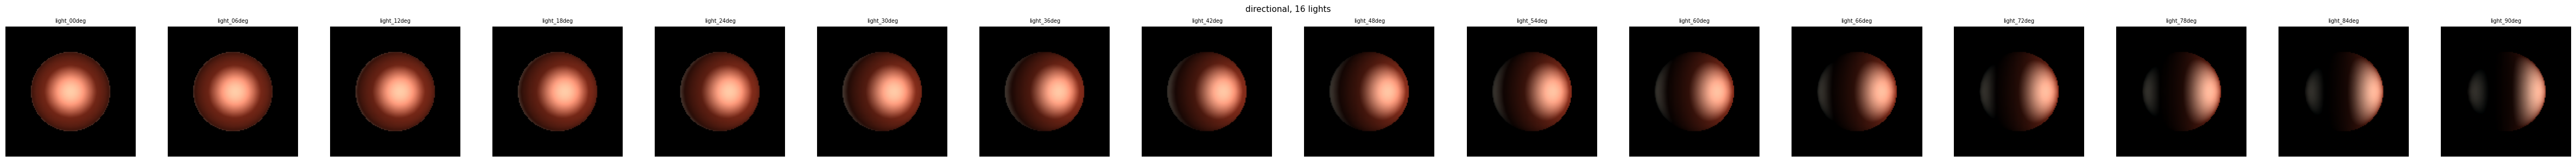

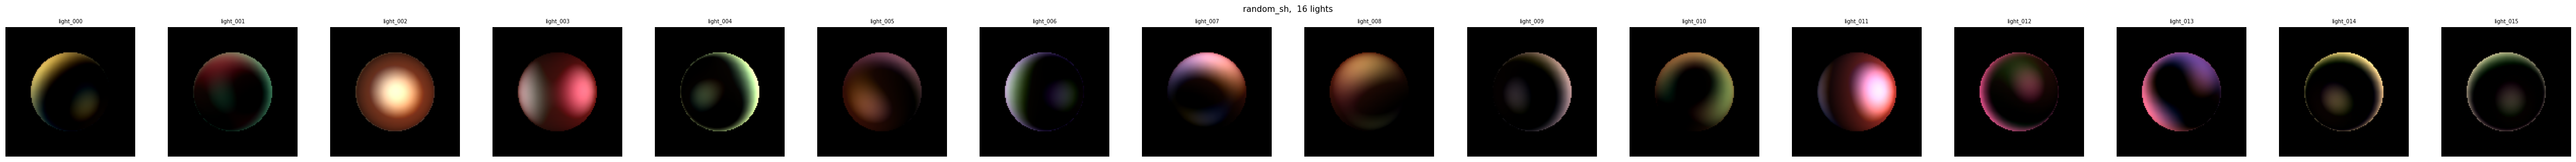

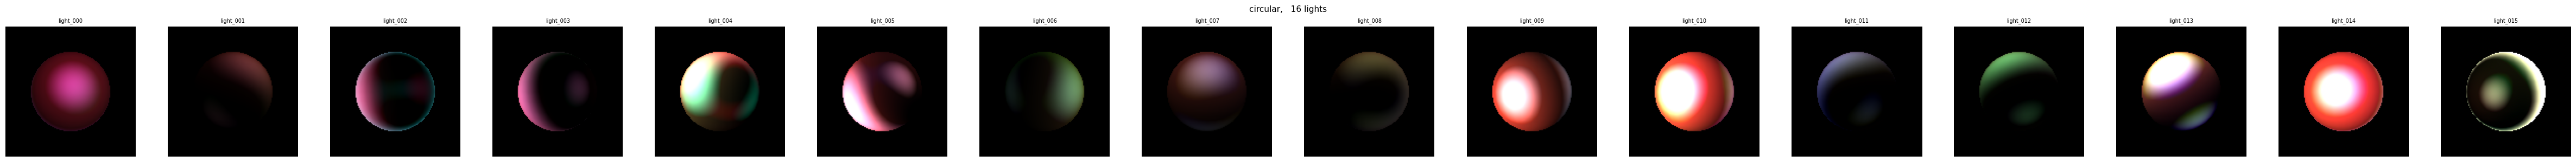

In [3]:
from PIL import Image

def show_renders(scene_name, shader="phong_sh", title=None):
    scene_dir = DATASET_ROOT / scene_name / shader
    light_dirs = sorted(scene_dir.iterdir()) if scene_dir.exists() else []
    if not light_dirs:
        print(f"No renders found for {scene_name}/{shader}")
        return
    n = len(light_dirs)
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    if n == 1: axes = [axes]
    fig.suptitle(title or scene_name, fontsize=11)
    for ax, ld in zip(axes, light_dirs):
        img_path = ld / "render.png"
        if img_path.exists():
            ax.imshow(Image.open(img_path))
        ax.set_title(ld.name, fontsize=7)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_renders(f"sphere_phong_albedo_0_dir{N_LIGHTS}",  title=f"directional, {N_LIGHTS} lights")
show_renders(f"sphere_phong_albedo_0_rsh{N_LIGHTS}",  title=f"random_sh,  {N_LIGHTS} lights")
show_renders(f"sphere_phong_albedo_0_circ{N_LIGHTS}", title=f"circular,   {N_LIGHTS} lights")

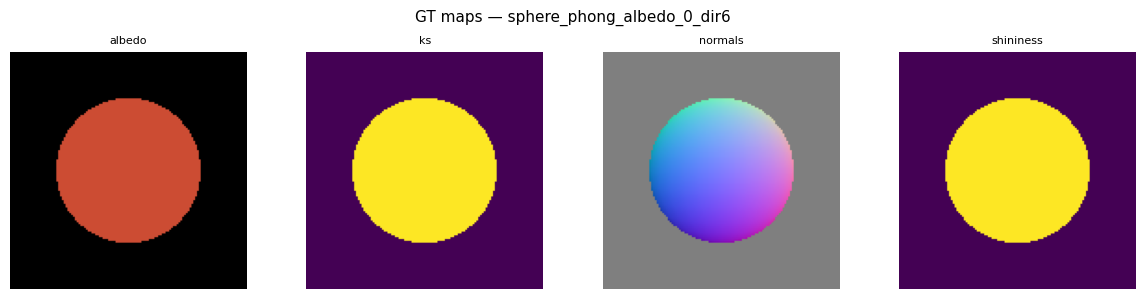

In [34]:
# Show GT material maps (albedo, normal)
def show_gt(scene_name):
    gt_dir = DATASET_ROOT / scene_name / "gt"
    if not gt_dir.exists():
        print(f"No GT at {gt_dir}"); return
    files = sorted(gt_dir.glob("*.png"))
    n = len(files)
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    if n == 1: axes = [axes]
    fig.suptitle(f"GT maps â€” {scene_name}", fontsize=11)
    for ax, f in zip(axes, files):
        ax.imshow(Image.open(f))
        ax.set_title(f.stem, fontsize=8)
        ax.axis("off")
    plt.tight_layout(); plt.show()

show_gt(f"sphere_phong_albedo_0_dir{N_LIGHTS}")

## 2 â€” Phase 2: decomposition

In [5]:
CFG = dict(n_iter=100, lbfgs_max_iter=10, log_every=5)

In [9]:
# # â”€â”€ 2a: standard init â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# run_decomposition(
#     mesh_name="sphere", width=128, height=128,
#     shader="phong_sh", device=DEVICE,
#     mat_configs_filter={"albedo_0"},
#     cfg_overrides=CFG,
#     light_mode="directional", n_lights=N_LIGHTS, full_circle=FULL_CIRCLE,
#     init_from_gt=False,
# )
# print("done: standard init")

In [10]:
# # â”€â”€ 2b: GT init â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# run_decomposition(
#     mesh_name="sphere", width=128, height=128,
#     shader="phong_sh", device=DEVICE,
#     mat_configs_filter={"albedo_0"},
#     cfg_overrides=CFG,
#     light_mode="directional", n_lights=N_LIGHTS, full_circle=FULL_CIRCLE,
#     init_from_gt=True,
# )
# print("done: GT init")

In [ ]:
# â”€â”€ 2c: gradient logging â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
run_decomposition(
    mesh_name="sphere", width=128, height=128,
    shader="phong_sh", device=DEVICE,
    mat_configs_filter={"albedo_0"},
    cfg_overrides={**CFG, "n_iter": 100},
    light_mode="directional", n_lights=N_LIGHTS, full_circle=FULL_CIRCLE,
    init_from_gt=False,
    log_gradients=True,
)
print("done: gradient logging")


[Phase 2] sphere_phong_albedo_0_dir6  (phong_sh)
  [init]          loss=2.629e-01  data=2.629e-01  shininess=128.5  ks=0.500
  [   0]    1.4s  loss=2.774e-03  data=2.774e-03  shininess=128.5  ks=0.496


In [13]:
# â”€â”€ 2d: GT init + gradient logging â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
run_decomposition(
    mesh_name="sphere", width=128, height=128,
    shader="phong_sh", device=DEVICE,
    mat_configs_filter={"albedo_0"},
    cfg_overrides={**CFG, "n_iter":20},
    light_mode="random_sh", n_lights=N_LIGHTS, full_circle=FULL_CIRCLE,
    init_from_gt=True,
    log_gradients=True,
)
print("done: GT init + log gradients")


[Phase 2] sphere_phong_albedo_0_rsh16  (phong_sh)
  [init]          loss=0.000e+00  data=0.000e+00  shininess=32.0  ks=0.500
  [   0]    0.6s  loss=0.000e+00  data=0.000e+00  shininess=32.0  ks=0.500
  [   5]    3.3s  loss=0.000e+00  data=0.000e+00  shininess=32.0  ks=0.500
  [  10]    6.2s  loss=0.000e+00  data=0.000e+00  shininess=32.0  ks=0.500
  [  15]    9.1s  loss=0.000e+00  data=0.000e+00  shininess=32.0  ks=0.500
  11.3s  albedo RMSE=0.0000  shininess=32.000(GT=32.000)  ks=0.500(GT=0.500)  -> C:\Users\felix\Documents\intrinsic decomposition\synthetic_ct\results\no_transforms\sphere_phong_albedo_0_rsh16\phong_sh_gtinit_gradlog
[Phase 2] Complete.
done: GT init + log gradients


In [6]:
# â”€â”€ 2e: random_sh lighting â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
run_decomposition(
    mesh_name="sphere", width=128, height=128,
    shader="phong_sh", device=DEVICE,
    mat_configs_filter={"albedo_0"},
    cfg_overrides=CFG,
    light_mode="random_sh", n_lights=N_LIGHTS,
    log_gradients=True,
)
print("done: random_sh")


[Phase 2] sphere_phong_albedo_0_rsh16  (phong_sh)
  [init]          loss=9.866e-01  data=9.866e-01  shininess=32.0  ks=0.500
  [   0]    2.1s  loss=2.498e-03  data=2.498e-03  shininess=32.0  ks=0.503
  [   5]   12.4s  loss=1.332e-03  data=1.332e-03  shininess=32.0  ks=0.483
  [  10]   23.3s  loss=7.511e-04  data=7.511e-04  shininess=32.0  ks=0.417
  [  15]   34.7s  loss=3.396e-04  data=3.396e-04  shininess=32.0  ks=0.378
  [  20]   45.4s  loss=2.242e-04  data=2.242e-04  shininess=32.0  ks=0.353
  [  25]   56.9s  loss=2.059e-04  data=2.059e-04  shininess=32.0  ks=0.344
  [  30]   68.1s  loss=1.961e-04  data=1.961e-04  shininess=32.0  ks=0.337
  [  35]   79.8s  loss=1.936e-04  data=1.936e-04  shininess=32.0  ks=0.332
  [  40]   91.9s  loss=1.859e-04  data=1.859e-04  shininess=32.0  ks=0.308
  [  45]  102.8s  loss=1.516e-04  data=1.516e-04  shininess=32.0  ks=0.251
  [  50]  113.4s  loss=1.159e-04  data=1.159e-04  shininess=32.0  ks=0.206
  [  55]  123.8s  loss=7.610e-05  data=7.610e-05 

In [14]:
# â”€â”€ 2f: log-shininess transform (only_shininess) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Reparametrizes shininess in log space: raw param p â†’ shininess = exp(p).
# Gradients then scale with current shininess value rather than being tiny
# absolute steps. Standard init: exp(log(sqrt(s_min*s_max))) = sqrt(1*256) = 16.
run_decomposition(
    mesh_name="sphere", width=128, height=128,
    shader="phong_sh", device=DEVICE,
    mat_configs_filter={"albedo_0"},
    cfg_overrides={**CFG, "n_iter": 100},
    light_mode="random_sh", n_lights=N_LIGHTS,
    log_gradients=True,
    transforms=NAMED_TRANSFORMS["only_shininess"],
    init_from_gt=True
)
print("done: log-shininess transform")


[Phase 2] sphere_phong_albedo_0_rsh16  (phong_sh)
  [init]          loss=0.000e+00  data=0.000e+00  shininess=32.0  ks=0.500
  [   0]    0.5s  loss=0.000e+00  data=0.000e+00  shininess=32.0  ks=0.500
  [   5]    3.4s  loss=0.000e+00  data=0.000e+00  shininess=32.0  ks=0.500
  [  10]    6.3s  loss=0.000e+00  data=0.000e+00  shininess=32.0  ks=0.500
  [  15]    9.3s  loss=0.000e+00  data=0.000e+00  shininess=32.0  ks=0.500
  [  20]   12.2s  loss=0.000e+00  data=0.000e+00  shininess=32.0  ks=0.500
  [  25]   15.1s  loss=0.000e+00  data=0.000e+00  shininess=32.0  ks=0.500
  [  30]   17.8s  loss=0.000e+00  data=0.000e+00  shininess=32.0  ks=0.500
  [  35]   20.6s  loss=0.000e+00  data=0.000e+00  shininess=32.0  ks=0.500
  [  40]   23.5s  loss=0.000e+00  data=0.000e+00  shininess=32.0  ks=0.500
  [  45]   26.4s  loss=0.000e+00  data=0.000e+00  shininess=32.0  ks=0.500
  [  50]   29.4s  loss=0.000e+00  data=0.000e+00  shininess=32.0  ks=0.500
  [  55]   32.2s  loss=0.000e+00  data=0.000e+00 

In [ ]:
# try ADAM

# run_decomposition(
#     mesh_name="sphere", width=128, height=128,
#     shader="phong_sh", device=DEVICE,
#     mat_configs_filter={"albedo_0"},
#     cfg_overrides=dict(optimizer = "ADAM", n_iter = 500, lr = 1e-4,),
#     light_mode="random_sh", n_lights=N_LIGHTS,
#     log_gradients=True,
# )
# print("done: random_sh")


[Phase 2] sphere_phong_albedo_0_rsh16  (phong_sh)
  [init]          loss=9.683e-01  data=9.683e-01  shininess=128.5  ks=0.500
  [   0]    0.6s  loss=9.683e-01  data=9.683e-01  shininess=128.5  ks=0.500
  [  20]   13.5s  loss=9.562e-01  data=9.562e-01  shininess=128.5  ks=0.498
  [  40]   26.7s  loss=9.445e-01  data=9.445e-01  shininess=128.5  ks=0.496
  [  60]   38.8s  loss=9.331e-01  data=9.331e-01  shininess=128.5  ks=0.494
  [  80]   50.1s  loss=9.221e-01  data=9.221e-01  shininess=128.5  ks=0.492
  [ 100]   61.2s  loss=9.113e-01  data=9.113e-01  shininess=128.5  ks=0.490
  [ 120]   72.2s  loss=9.009e-01  data=9.009e-01  shininess=128.5  ks=0.489
  [ 140]   82.9s  loss=8.907e-01  data=8.907e-01  shininess=128.5  ks=0.487
  [ 160]   93.8s  loss=8.808e-01  data=8.808e-01  shininess=128.5  ks=0.485
  [ 180]  104.6s  loss=8.712e-01  data=8.712e-01  shininess=128.5  ks=0.483
  [ 200]  115.2s  loss=8.618e-01  data=8.618e-01  shininess=128.5  ks=0.482
  [ 220]  126.2s  loss=8.527e-01  dat

## 3 â€” Inspect results


sphere_phong_albedo_0_rsh16 / phong_sh_gradlog
  recon_rmse: 4.424e-04
  albedo_rmse: 1.621e-02
  final_loss: 2.734e-05

  ks_est_mean: 1.193e-01
  ks_gt: 5.000e-01
  ks_err_mean: 3.807e-01

  shininess_est_mean: 3.200e+01
  shininess_gt: 3.200e+01
  shininess_err_mean: 7.177e-03


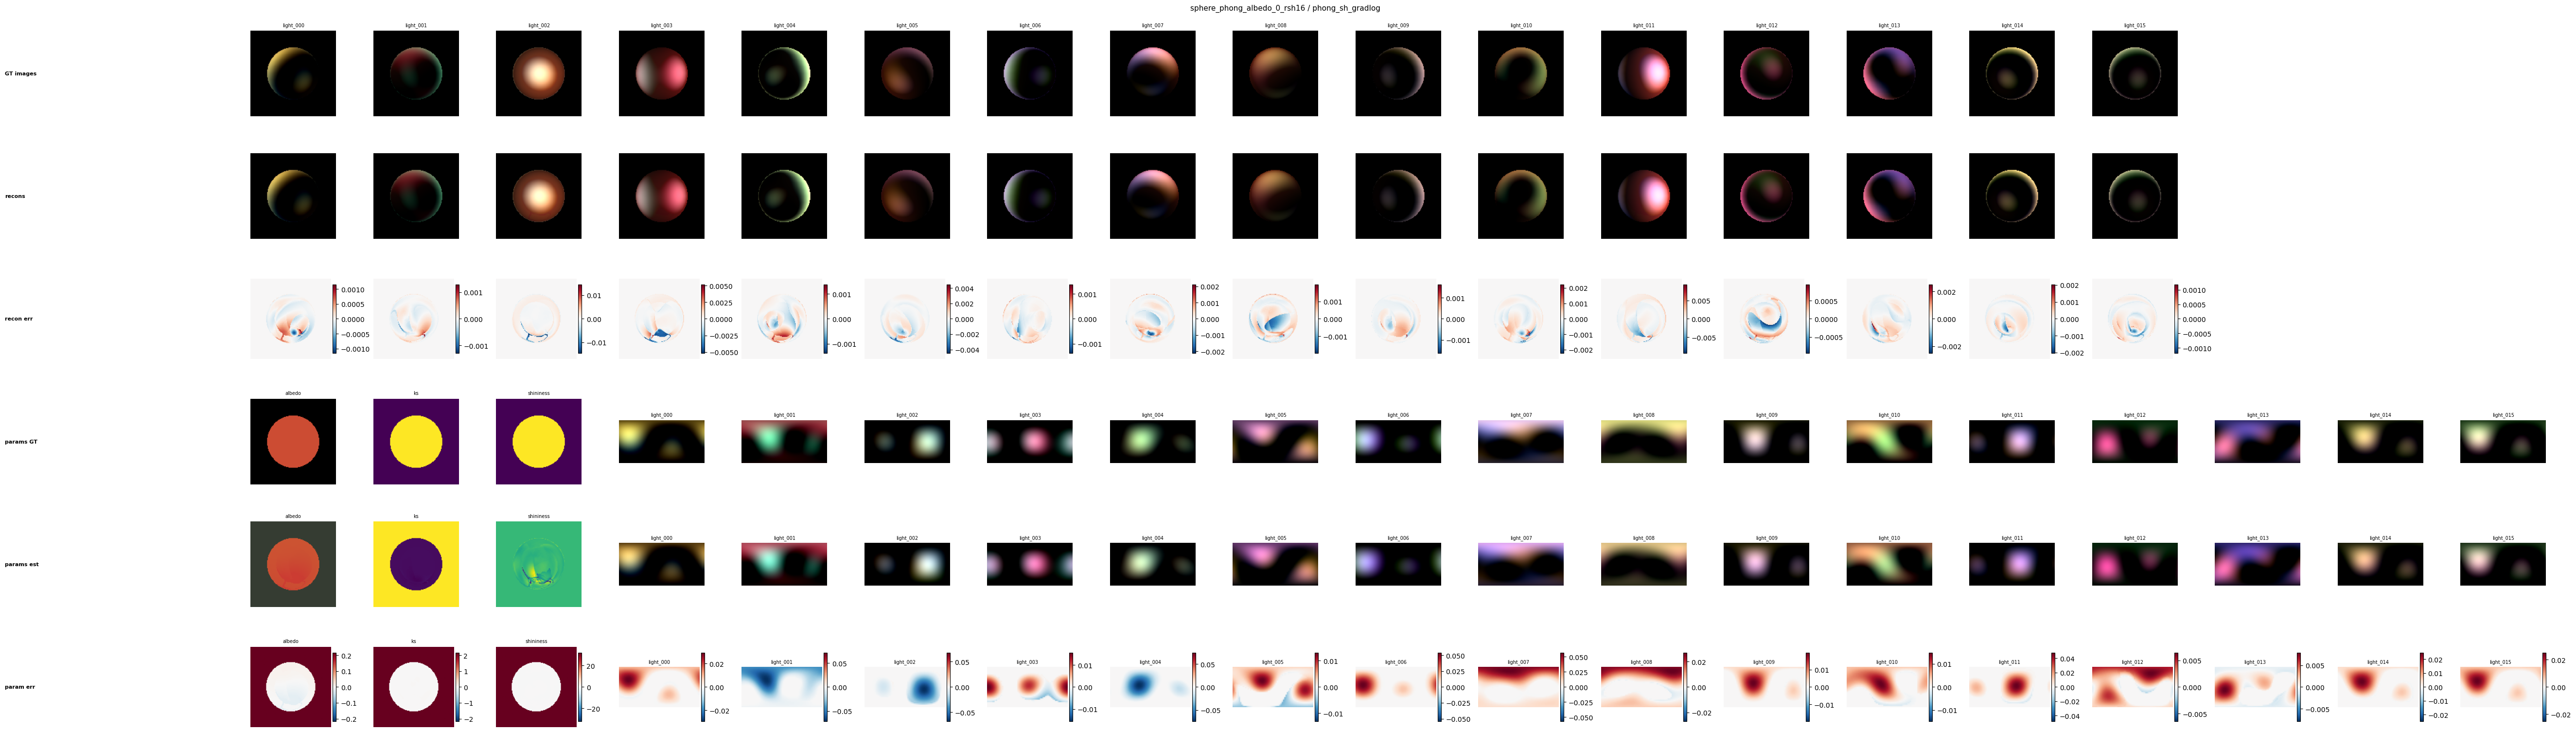

In [26]:
def results_dir(scene, shader_folder, tr="no_transforms"):
    return RESULTS_ROOT / tr / scene / shader_folder

def show_results(scene, shader_folder, tr="no_transforms"):
    d = results_dir(scene, shader_folder, tr)
    if not d.exists():
        print(f"Not found: {d}"); return

    scene_ds = DATASET_ROOT / scene

    # â”€â”€ find base shader dir in dataset (strip _gtinit/_gradlog suffixes) â”€â”€â”€â”€
    shader_base = None
    parts = shader_folder.split("_")
    for i in range(len(parts), 0, -1):
        cand = "_".join(parts[:i])
        if (scene_ds / cand).is_dir():
            shader_base = cand; break

    # â”€â”€ light keys â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    meta_path = scene_ds / "dataset_meta.json"
    if meta_path.exists():
        light_keys = json.loads(meta_path.read_text())["light_keys"]
    elif shader_base:
        light_keys = sorted(p.name for p in (scene_ds / shader_base).iterdir() if p.is_dir())
    else:
        light_keys = []
    N_L = max(len(light_keys), 1)

    SHIN_MAX = float(SHININESS_RANGE[1])   # 256

    # â”€â”€ file helpers â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    def load_float(path):
        path = Path(path)
        npy = path.with_suffix(".npy")
        if npy.exists():  return np.load(npy).astype(np.float32)
        if path.exists(): return np.array(Image.open(path), dtype=np.float32) / 255.0
        return None

    def load_first(*paths):
        for p in paths:
            result = load_float(p)
            if result is not None:
                return result
        return None

    def load_param(base_dir, stem, pn):
        """Load in actual physical units: .npy preferred; PNG fallback denormalises shininess."""
        base_dir = Path(base_dir)
        npy = base_dir / f"{stem}.npy"
        png = base_dir / f"{stem}.png"
        if npy.exists():
            return np.load(npy).astype(np.float32)
        if png.exists():
            v = np.array(Image.open(png), dtype=np.float32) / 255.0
            return v * SHIN_MAX if pn == "shininess" else v
        return None

    def to_rgb(img):
        if img is None: return None
        if img.ndim == 2: return np.stack([img] * 3, -1)
        return img[..., :3]

    def param_for_display(data, pn):
        """Normalise actual-unit param to [0,1] for imshow."""
        if data is None: return None
        v = to_rgb(data)
        return (v / SHIN_MAX).clip(0, 1) if pn == "shininess" else v.clip(0, 1)

    # â”€â”€ metrics â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    metrics = json.loads((d / "metrics.json").read_text()) if (d / "metrics.json").exists() else {}
    albedo_scale = np.array(metrics.get("albedo_scale", [1.0, 1.0, 1.0]), dtype=np.float32)
    ks_scale = float(np.mean(albedo_scale))

    print(f"\n{'='*60}\n{scene} / {shader_folder}")
    for k in ("recon_rmse", "albedo_rmse", "final_loss"):
        if k in metrics:
            print(f"  {k}: {metrics[k]:.3e}")
    param_labels = sorted(k[:-9] for k in metrics if k.endswith("_est_mean"))
    for pl in param_labels:
        print()
        for suffix in ("_est_mean", "_gt", "_err_mean"):
            k = pl + suffix
            if k in metrics:
                print(f"  {k}: {metrics[k]:.3e}")

    # â”€â”€ GT renders â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    gt_renders = [
        load_float(scene_ds / shader_base / lk / "render.png") if shader_base else None
        for lk in light_keys
    ]

    # â”€â”€ reconstructions (prefer .npy, float unclamped) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    recon_dir = d / "reconstructions"
    recon_list = [None] * N_L
    if recon_dir.exists():
        recon_files = {f.stem[len("recon_"):]: load_float(f)
                       for f in sorted(recon_dir.glob("recon_*.png"))
                       if not f.stem.startswith("recon_err")}
        keyed = [recon_files.get(lk) for lk in light_keys]
        if any(r is not None for r in keyed):
            recon_list = keyed
        else:
            vals = list(recon_files.values())
            recon_list = vals[:N_L] + [None] * (N_L - len(vals))

    # â”€â”€ signed recon error (recon âˆ’ GT, mean over RGB) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    recon_err_list = [
        (to_rgb(rc) - to_rgb(gt)).mean(-1)
        if rc is not None and gt is not None else None
        for rc, gt in zip(recon_list, gt_renders)
    ]

    # â”€â”€ params in actual units â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    spatial_params = [f.stem[:-4] for f in sorted(d.glob("*_est.png"))]
    gt_dir = scene_ds / "gt"
    est_actual = {pn: load_param(d,      f"{pn}_est", pn) for pn in spatial_params}
    gt_actual  = {pn: load_param(gt_dir,  pn,         pn) for pn in spatial_params}
    err_actual = {pn: load_param(d,      f"{pn}_err", pn) for pn in spatial_params}

    # â”€â”€ env maps â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    gt_env_maps = [
        load_first(scene_ds / shader_base / lk / "sh_env_map.png",
                   scene_ds / shader_base / lk / "env_map.png")
        if shader_base else None
        for lk in light_keys
    ]
    est_env_maps = [
        load_first(d / f"sh_env_map_{lk}.png",
                   d / f"env_map_{lk}.png")
        for lk in light_keys
    ]
    has_env = any(e is not None for e in est_env_maps)

    # â”€â”€ signed param errors â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    def param_err(pn):
        ep, gp = est_actual.get(pn), gt_actual.get(pn)
        if ep is not None and gp is not None:
            if pn == "albedo":
                ep_corr = (to_rgb(ep) * albedo_scale).clip(0, 1)
                return (ep_corr - to_rgb(gp)).mean(-1)
            elif pn == "ks":
                ep_corr = to_rgb(ep) * ks_scale
                return (ep_corr - to_rgb(gp)).mean(-1)
            else:
                return (to_rgb(ep) - to_rgb(gp)).mean(-1)
        e = err_actual.get(pn)
        return to_rgb(e).mean(-1) if e is not None else None

    env_err = [
        (to_rgb(ge) - to_rgb(ee)).mean(-1)
        if ge is not None and ee is not None else None
        for ge, ee in zip(gt_env_maps, est_env_maps)
    ]

    # â”€â”€ display arrays (normalised [0,1]) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    gt_disp  = {pn: param_for_display(gt_actual.get(pn), pn)  for pn in spatial_params}
    est_disp = {}
    for pn in spatial_params:
        ep = est_actual.get(pn)
        if pn == "albedo" and ep is not None:
            ep = (to_rgb(ep) * albedo_scale).clip(0, 1)
        elif pn == "ks" and ep is not None:
            ep = (to_rgb(ep) * ks_scale).clip(0, 1)
        est_disp[pn] = param_for_display(ep, pn)

    # â”€â”€ column layout â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    param_col_names = spatial_params + (light_keys if has_env else [])
    N_cols = max(N_L, len(param_col_names), 1)

    def param_row(items_spatial, items_env):
        items = items_spatial + (items_env if has_env else [])
        return items + [None] * (N_cols - len(items))

    rows_spec = [
        ("GT images",  gt_renders     + [None] * (N_cols - N_L), light_keys, False),
        ("recons",     recon_list     + [None] * (N_cols - N_L), light_keys, False),
        ("recon err",  recon_err_list + [None] * (N_cols - N_L), light_keys, True),
        ("params GT",  param_row([gt_disp.get(p)   for p in spatial_params], gt_env_maps),
                       param_col_names, False),
        ("params est", param_row([est_disp.get(p)  for p in spatial_params], est_env_maps),
                       param_col_names, False),
        ("param err",  param_row([param_err(p)      for p in spatial_params], env_err),
                       param_col_names, True),
    ]

    n_rows = len(rows_spec)
    fig, axes = plt.subplots(n_rows, N_cols,
                             figsize=(2.8 * N_cols, 2.6 * n_rows), squeeze=False)
    fig.suptitle(f"{scene} / {shader_folder}", fontsize=11)

    for ri, (rlabel, items, col_lbls, is_err) in enumerate(rows_spec):
        for ci in range(N_cols):
            ax  = axes[ri, ci]
            img = items[ci] if ci < len(items) else None

            if ri == 0 and ci < len(col_lbls):
                ax.set_title(col_lbls[ci], fontsize=7)
            elif rlabel in ("params GT", "params est", "param err") and ci < len(col_lbls):
                ax.set_title(col_lbls[ci], fontsize=7)

            if img is None:
                ax.axis("off"); continue

            if is_err:
                vmax = float(np.nanmax(np.abs(img))) or 1e-6
                im = ax.imshow(img, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
                plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
            else:
                ax.imshow(to_rgb(img).clip(0, 1))

            ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
            for spine in ax.spines.values():
                spine.set_visible(False)

    plt.tight_layout()
    plt.subplots_adjust(left=0.1)
    for ri, (rlabel, *_) in enumerate(rows_spec):
        pos = axes[ri, 0].get_position()
        fig.text(0.005, (pos.y0 + pos.y1) / 2, rlabel,
                 fontsize=8, fontweight="bold", ha="left", va="center")
    plt.show()

# show_results(scene_id(), "phong_sh_gradlog")
show_results(scene_id(mode="random_sh"), "phong_sh_gradlog")
# random_sh results
# show_results(scene_id(mode="random_sh"), "phong_sh")
# show_results(scene_id(), "phong_sh_gradlog")
# show_results(scene_id(mode="random_sh"), "phong_sh_gradlog")
# GT init + gradlog
# show_results(scene_id(), "phong_sh_gtinit_gradlog")

## 4 â€” Gradient flow inspection

In [6]:
N_LIGHTS

16

In [27]:
# grad_dir = results_dir(scene_id(), "phong_sh_gradlog") / "gradient_flow"
# grad_dir = results_dir(scene_id(mode="random_sh"), "phong_sh_gradlog") / "gradient_flow"
# grad_dir = results_dir(scene_id(mode="random_sh"), "phong_sh_gtinit_gradlog") / "gradient_flow"
# grad_dir = results_dir(scene_id(), "phong_sh_gtinit_gradlog") / "gradient_flow"
# grad_dir = results_dir(scene_id(mode="random_sh"), "phong_sh_gradlog", tr="only_shininess_transforms") / "gradient_flow"
grad_dir = results_dir(scene_id(mode="random_sh"), "phong_sh_gtinit_gradlog", tr="only_shininess_transforms") / "gradient_flow"
npz_files = sorted(grad_dir.glob("step_*.npz")) if grad_dir.exists() else []
print(f"Gradient snapshots: {len(npz_files)}")
if npz_files:
    sample = np.load(npz_files[0])
    print("Keys:", list(sample.keys()))

Gradient snapshots: 100
Keys: ['loss_total', 'loss_data', 'loss_sparse', 'loss_white', 'loss_tv', 'albedo_raw', 'albedo_update', 'albedo_grad', 'albedo_value', 'albedo_gt_error', 'sh_raw', 'sh_update', 'sh_grad', 'sh_value', 'sh_gt_error', 'shininess_raw', 'shininess_update', 'shininess_grad', 'shininess_value', 'shininess_gt_error', 'ks_raw', 'ks_update', 'ks_grad', 'ks_value', 'ks_gt_error', 'shade_k00_irr', 'shade_k00_diff', 'shade_k00_R', 'shade_k00_L_spec', 'shade_k00_spec', 'shade_k01_irr', 'shade_k01_diff', 'shade_k01_R', 'shade_k01_L_spec', 'shade_k01_spec', 'shade_k02_irr', 'shade_k02_diff', 'shade_k02_R', 'shade_k02_L_spec', 'shade_k02_spec', 'shade_k03_irr', 'shade_k03_diff', 'shade_k03_R', 'shade_k03_L_spec', 'shade_k03_spec', 'shade_k04_irr', 'shade_k04_diff', 'shade_k04_R', 'shade_k04_L_spec', 'shade_k04_spec', 'shade_k05_irr', 'shade_k05_diff', 'shade_k05_R', 'shade_k05_L_spec', 'shade_k05_spec', 'shade_k06_irr', 'shade_k06_diff', 'shade_k06_R', 'shade_k06_L_spec', 'shad

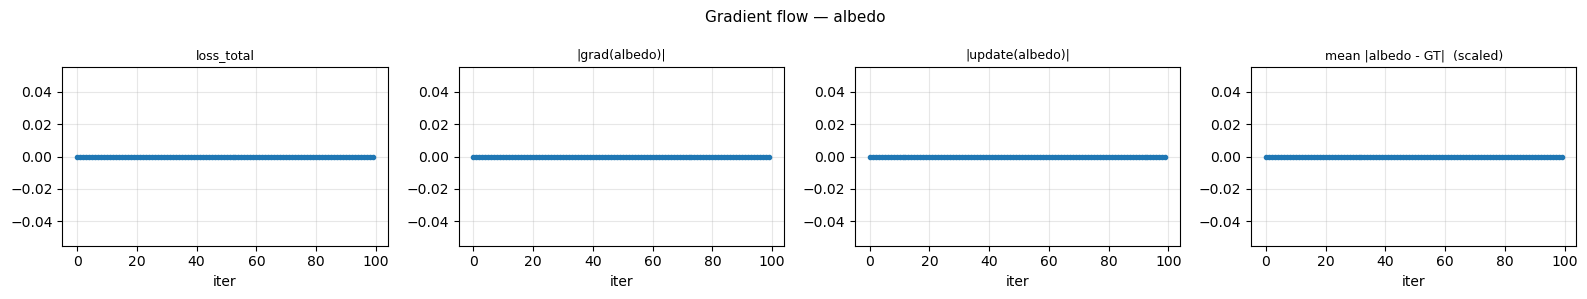

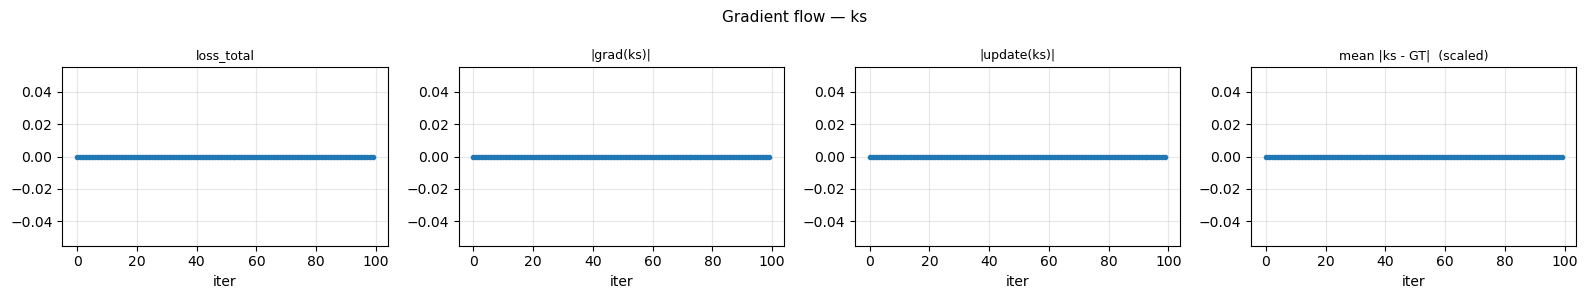

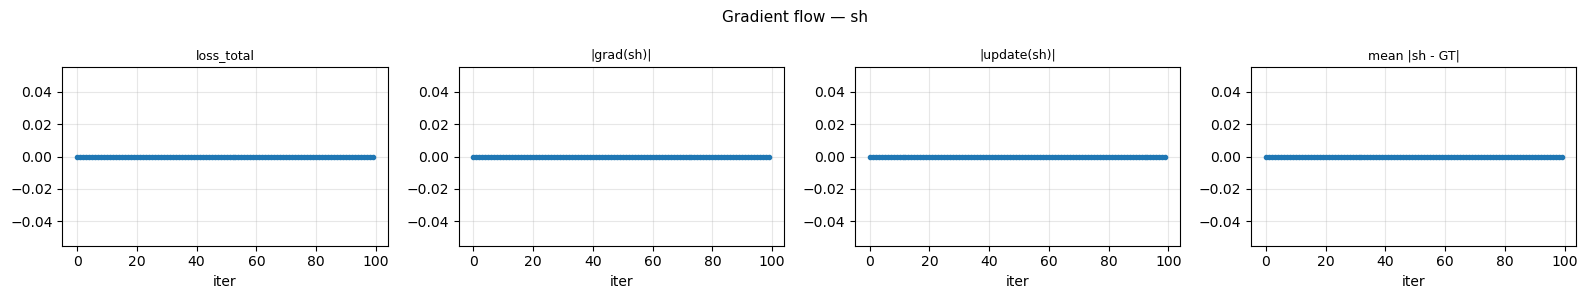

In [32]:
def plot_grad_flow(grad_dir, param="albedo"):
    npz_files = sorted(Path(grad_dir).glob("step_*.npz"))
    if not npz_files:
        print("No gradient snapshots found.")
        return

    albedo_scale = np.ones(3, dtype=np.float32)
    metrics_path = Path(grad_dir).parent / "metrics.json"
    if metrics_path.exists():
        m = json.loads(metrics_path.read_text())
        if "albedo_scale" in m:
            albedo_scale = np.array(m["albedo_scale"], dtype=np.float32)
    ks_scale = float(np.mean(albedo_scale))

    steps, grad_norms, update_norms, gt_errors = [], [], [], []
    losses = []
    for f in npz_files:
        d = np.load(f)
        steps.append(int(f.stem.split("_")[1]))
        gk = f"{param}_grad"
        uk = f"{param}_update"
        ek = f"{param}_gt_error"
        if gk in d: grad_norms.append(float(np.linalg.norm(d[gk])))
        if uk in d: update_norms.append(float(np.linalg.norm(d[uk])))
        if ek in d:
            err = d[ek]
            if param == "albedo":
                err = err * albedo_scale
            elif param == "ks" and f"{param}_value" in d:
                ks_GT_map = d[f"{param}_value"] - err
                err = d[f"{param}_value"] * ks_scale - ks_GT_map
            gt_errors.append(float(np.abs(err).mean()))
        if "loss_total" in d: losses.append(float(d["loss_total"]))

    scaled_note = "  (scaled)" if param in ("albedo", "ks") else ""
    fig, axes = plt.subplots(1, 4, figsize=(16, 3))
    fig.suptitle(f"Gradient flow â€” {param}", fontsize=11)
    for ax, (vals, label) in zip(axes, [
        (losses, "loss_total"),
        (grad_norms, f"|grad({param})|"),
        (update_norms, f"|update({param})|"),
        (gt_errors, f"mean |{param} - GT|{scaled_note}"),
    ]):
        if vals:
            ax.plot(steps[:len(vals)], vals, marker=".")
        ax.set_title(label, fontsize=9)
        ax.set_xlabel("iter")
        ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

plot_grad_flow(grad_dir, param="albedo")
plot_grad_flow(grad_dir, param="ks")
plot_grad_flow(grad_dir, param="sh")

In [42]:
def plot_top_error_pixel_details(grad_dir, scene_name, shader, n_top=5, rank_by="albedo"):
    from raw_optimizer.synthetic_ct_dataset import DATASET_ROOT

    npz_files = sorted(Path(grad_dir).glob("step_*.npz"))
    if not npz_files:
        print("No gradient snapshots."); return
    steps = [int(f.stem.split("_")[1]) for f in npz_files]

    # â”€â”€ target images + foreground mask â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    meta_path = DATASET_ROOT / scene_name / "dataset_meta.json"
    light_keys = json.loads(meta_path.read_text())["light_keys"] if meta_path.exists() else []
    target_imgs = []
    for lk in light_keys:
        img_path = DATASET_ROOT / scene_name / shader / lk / "render.png"
        npy_path  = img_path.with_suffix(".npy")
        if npy_path.exists():
            target_imgs.append(np.load(npy_path).astype(np.float32))
        elif img_path.exists():
            target_imgs.append(np.array(Image.open(img_path), dtype=np.float32) / 255.0)
    if not target_imgs:
        print(f"No target images for {scene_name}/{shader}"); return

    H, W   = target_imgs[0].shape[:2]
    N_L    = len(target_imgs)
    mask2d = np.zeros((H, W), dtype=bool)
    for img in target_imgs:
        mask2d |= (img.max(-1) > 1e-6)

    # â”€â”€ albedo/ks scale (needed for ranking and display) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    albedo_scale = np.ones(3, dtype=np.float32)
    metrics_path = Path(grad_dir).parent / "metrics.json"
    if metrics_path.exists():
        m = json.loads(metrics_path.read_text())
        if "albedo_scale" in m:
            albedo_scale = np.array(m["albedo_scale"], dtype=np.float32)
            print(f"albedo_scale: {np.round(albedo_scale, 4).tolist()}")
    ks_scale = float(np.mean(albedo_scale))

    # â”€â”€ rank foreground pixels by final-step error â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    final = np.load(npz_files[-1])
    if rank_by == "recon":
        recon_err_final = np.zeros((H, W), dtype=np.float32)
        n_valid = 0
        for ki in range(N_L):
            pref = f"shade_k{ki:02d}_"
            if f"{pref}diff" in final and f"{pref}spec" in final:
                recon = final[f"{pref}diff"] + final[f"{pref}spec"]
                recon_err_final += np.abs(recon - target_imgs[ki]).mean(-1)
                n_valid += 1
        err_mag = (recon_err_final / max(n_valid, 1)) * mask2d
    else:
        err_arr = final[f"{rank_by}_gt_error"]
        if rank_by == "albedo":
            err_arr = err_arr * albedo_scale
        elif rank_by == "ks" and "ks_value" in final:
            ks_GT_map = final["ks_value"] - err_arr
            err_arr   = final["ks_value"] * ks_scale - ks_GT_map
        err_mag = np.abs(err_arr).mean(-1) * mask2d

    flat_idx = np.argsort(err_mag.ravel())[::-1][:n_top]
    pix_rc   = [(i // W, i % W) for i in flat_idx]

    # â”€â”€ collect per-step data â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    spatial_params = [p for p in ("albedo", "shininess", "ks", "metallic", "roughness")
                      if f"{p}_update" in final]
    quantities     = ["value", "update", "grad", "gt_error"]

    pdata = {p: {q: [] for q in quantities} for p in spatial_params}
    recon_err = []   # (n_steps, n_top, N_L)

    for f in npz_files:
        d = np.load(f)
        for p in spatial_params:
            for q in quantities:
                key = f"{p}_{q}"
                if key in d:
                    arr = d[key]
                    pdata[p][q].append(np.array([arr[r, c] for r, c in pix_rc]))

        step_err = np.zeros((n_top, N_L))
        for ki in range(N_L):
            pref = f"shade_k{ki:02d}_"
            if f"{pref}diff" in d and f"{pref}spec" in d:
                recon = d[f"{pref}diff"] + d[f"{pref}spec"]
                per_px = np.abs(recon - target_imgs[ki]).mean(-1)
                for pi, (r, c) in enumerate(pix_rc):
                    step_err[pi, ki] = per_px[r, c]
        recon_err.append(step_err)

    recon_err = np.stack(recon_err)                                     # (n_steps, n_top, N_L)
    pdata     = {p: {q: np.stack(v) for q, v in qs.items() if v}
                 for p, qs in pdata.items()}

    # â”€â”€ scale corrections on pdata (albedo and ks share the SH scale) â”€â”€â”€â”€â”€â”€â”€â”€
    if "albedo" in pdata and "value" in pdata["albedo"] and "gt_error" in pdata["albedo"]:
        gt_albedo_raw = pdata["albedo"]["value"][0] - pdata["albedo"]["gt_error"][0]
        pdata["albedo"]["value"]    = pdata["albedo"]["value"]    * albedo_scale
        pdata["albedo"]["gt_error"] = pdata["albedo"]["value"]    - gt_albedo_raw

    if "ks" in pdata and "value" in pdata["ks"] and "gt_error" in pdata["ks"]:
        gt_ks_raw = pdata["ks"]["value"][0] - pdata["ks"]["gt_error"][0]   # (n_top, 1)
        pdata["ks"]["value"]    = pdata["ks"]["value"]    * ks_scale
        pdata["ks"]["gt_error"] = pdata["ks"]["value"]    - gt_ks_raw

    gt_vals = {}
    for p in spatial_params:
        if "value" in pdata[p] and "gt_error" in pdata[p]:
            gt_vals[p] = pdata[p]["value"][0] - pdata[p]["gt_error"][0]  # (n_top, C)

    # â”€â”€ location map â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(err_mag, cmap="hot")
    for i, (r, c) in enumerate(pix_rc):
        ax.scatter(c, r, s=120, marker="*", color="cyan", zorder=5)
        ax.text(c + 1, r - 1, str(i + 1), color="cyan", fontsize=8, fontweight="bold")
    if rank_by == "recon":
        rank_label = "mean recon err"
    elif rank_by == "albedo":
        rank_label = "|albedoâˆ’GT| (scaled)"
    elif rank_by == "ks":
        rank_label = "|ksâˆ’GT| (scaled)"
    else:
        rank_label = f"|{rank_by}âˆ’GT|"
    ax.set_title(f"Top-{n_top} foreground pixels by {rank_label}", fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.04)
    plt.tight_layout(); plt.show()

    # â”€â”€ per-pixel figures â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    ch_colors    = ["#e41a1c", "#4daf4a", "#377eb8"]
    light_colors = plt.cm.tab20.colors
    ch_labels    = {"albedo": ["R", "G", "B"], "shininess": ["shin"], "ks": ["ks"],
                    "metallic": ["met"], "roughness": ["rough"]}
    qty_labels   = {"value": "value (albedo: scale-corrected)", "update": "Î”/step",
                    "grad": "gradient", "gt_error": "error vs GT"}

    # row 0: 2 cols (all lights | mean), rows 1+: params Ã— len(quantities) cols
    n_cols = max(len(quantities), 2)
    n_rows = 1 + len(spatial_params)

    for pix_i, (r, c) in enumerate(pix_rc):
        fig, axes = plt.subplots(n_rows, n_cols,
                                 figsize=(3.5 * n_cols, 2.5 * n_rows), squeeze=False)
        err_label = (f"recon err = {err_mag[r, c]:.4f}" if rank_by == "recon"
                     else f"|{rank_by}âˆ’GT| = {err_mag[r, c]:.4f}")
        fig.suptitle(f"Pixel #{pix_i+1}  ({r}, {c})   {err_label}", fontsize=11)

        # Row 0 col 0: all lights as individual lines
        ax0 = axes[0, 0]
        for ki in range(N_L):
            ax0.plot(steps, recon_err[:, pix_i, ki],
                     color=light_colors[ki % len(light_colors)],
                     lw=1, alpha=0.7, label=f"L{ki}")
        ax0.set_title("recon |err| â€” all lights", fontsize=8)
        ax0.set_xlabel("iter", fontsize=7)
        ax0.axhline(0, color="k", lw=0.5, ls="--", alpha=0.4)
        ax0.grid(True, alpha=0.3)
        if N_L <= 10:
            ax0.legend(fontsize=5, ncol=2, loc="upper right")

        # Row 0 col 1: mean across lights
        ax1 = axes[0, 1]
        ax1.plot(steps, recon_err[:, pix_i, :].mean(-1), color="purple", lw=1.5)
        ax1.set_title("recon |err| mean", fontsize=8)
        ax1.set_xlabel("iter", fontsize=7)
        ax1.axhline(0, color="k", lw=0.5, ls="--", alpha=0.4)
        ax1.grid(True, alpha=0.3)

        for col_i in range(2, n_cols):
            axes[0, col_i].axis("off")

        # Rows 1+: spatial params Ã— quantities
        for row_off, p in enumerate(spatial_params):
            row_i = row_off + 1
            for col_i, q in enumerate(quantities):
                ax = axes[row_i, col_i]
                if q in pdata[p]:
                    vals = pdata[p][q][:, pix_i, :]   # (n_steps, C)
                    for ch in range(vals.shape[-1]):
                        lbl = ch_labels.get(p, [str(ch)])[ch] \
                              if ch < len(ch_labels.get(p, [])) else str(ch)
                        ax.plot(steps, vals[:, ch], marker=".",
                                color=ch_colors[ch % 3], label=lbl, lw=1.5)
                    if q == "value" and p in gt_vals:
                        for ch, gv in enumerate(gt_vals[p][pix_i]):
                            ax.axhline(gv, color=ch_colors[ch % 3],
                                       lw=1, ls="--", alpha=0.6)
                ax.axhline(0, color="k", lw=0.5, ls="--", alpha=0.4)
                ax.set_title(f"{p} â€” {qty_labels.get(q, q)}", fontsize=8)
                ax.set_xlabel("iter", fontsize=7)
                ax.legend(fontsize=6, loc="best")
                ax.grid(True, alpha=0.3)
            for col_i in range(len(quantities), n_cols):
                axes[row_i, col_i].axis("off")

        plt.tight_layout()
        plt.show()

albedo_scale: [1.0, 1.0, 1.0]


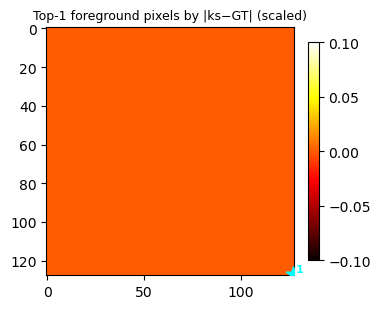

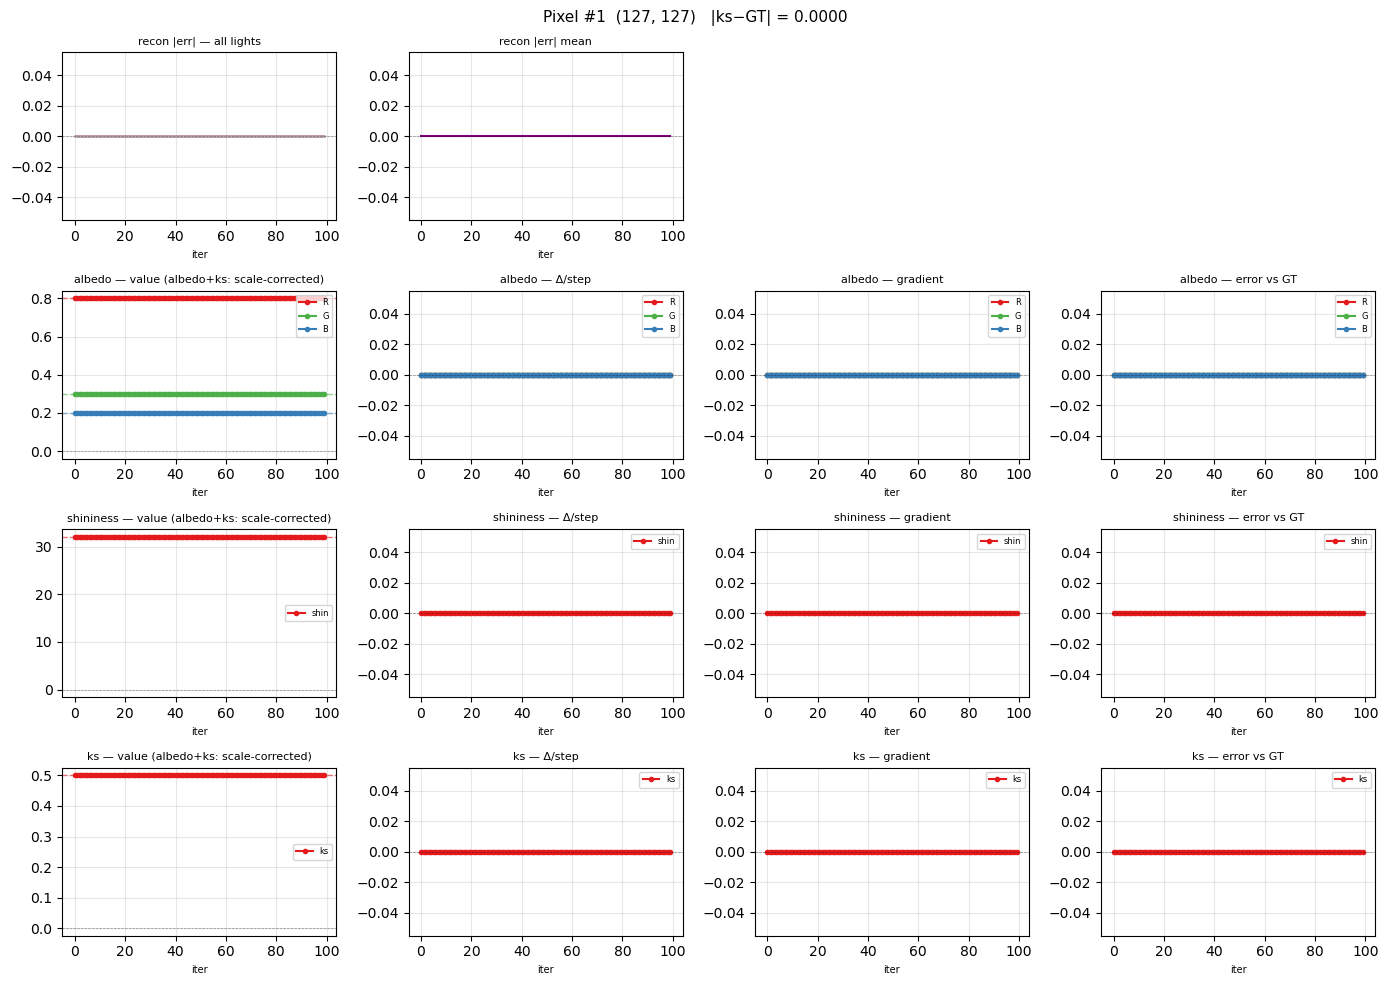

In [16]:
# plot_top_error_pixel_details(grad_dir, scene_id(mode="random_sh"), "phong_sh", n_top=1, rank_by="recon")
# plot_top_error_pixel_details(grad_dir, scene_id(mode="random_sh"), "phong_sh", n_top=1, rank_by="albedo")
plot_top_error_pixel_details(grad_dir, scene_id(mode="random_sh"), "phong_sh", n_top=1, rank_by="ks")
# plot_top_error_pixel_details(grad_dir, scene_id(mode="random_sh"), "phong_sh", n_top=1, rank_by="shininess")

In [ ]:
# Visualise albedo error map at first and last step
def show_grad_maps(grad_dir, param="albedo", key="gt_error"):
    npz_files = sorted(Path(grad_dir).glob("step_*.npz"))
    if not npz_files:
        print("No snapshots."); return

    albedo_scale = np.ones(3, dtype=np.float32)
    metrics_path = Path(grad_dir).parent / "metrics.json"
    if metrics_path.exists():
        m = json.loads(metrics_path.read_text())
        if "albedo_scale" in m:
            albedo_scale = np.array(m["albedo_scale"], dtype=np.float32)
    ks_scale = float(np.mean(albedo_scale))

    picks = [npz_files[0], npz_files[-1]]
    labels = ["step 0 (init)", f"step {len(npz_files)-1} (final)"]
    scale_note = "  (scaled)" if param in ("albedo", "ks") and key == "gt_error" else ""
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    fig.suptitle(f"{param}_{key}{scale_note}", fontsize=11)
    for ax, f, lbl in zip(axes, picks, labels):
        d = np.load(f)
        k = f"{param}_{key}"
        if k not in d:
            ax.set_title(f"{lbl}\n(key missing)"); ax.axis("off"); continue
        arr = d[k]
        if param == "albedo" and key == "gt_error":
            arr = arr * albedo_scale
        elif param == "ks" and key == "gt_error":
            ks_val = d.get(f"{param}_value")
            if ks_val is not None:
                ks_GT_map = ks_val - arr
                arr = ks_val * ks_scale - ks_GT_map
        if arr.ndim == 3 and arr.shape[-1] >= 3:
            ax.imshow(np.abs(arr).mean(-1), cmap="hot")
        elif arr.ndim == 3:
            ax.imshow(np.abs(arr[..., 0]), cmap="hot")
        else:
            ax.imshow(np.abs(arr), cmap="hot")
        ax.set_title(lbl, fontsize=9); ax.axis("off")
        plt.colorbar(ax.images[0], ax=ax, fraction=0.04)
    plt.tight_layout(); plt.show()

show_grad_maps(grad_dir, "albedo", "gt_error")
show_grad_maps(grad_dir, "albedo", "grad")

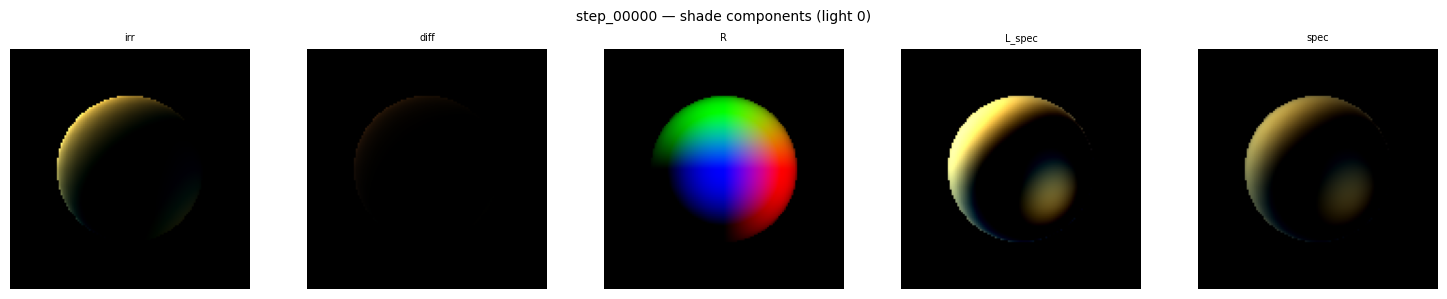

In [22]:
# Shade components at step 0 â€” e.g. diffuse, specular
def show_shade_components(grad_dir, step=0, light_idx=0):
    f = sorted(Path(grad_dir).glob("step_*.npz"))[step]
    d = np.load(f)
    comp_keys = [k for k in d.keys() if k.startswith(f"shade_k{light_idx:02d}_")]
    if not comp_keys:
        print(f"No shade components for light k{light_idx:02d} in {f.name}"); return
    n = len(comp_keys)
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    if n == 1: axes = [axes]
    fig.suptitle(f"{f.stem} â€” shade components (light {light_idx})", fontsize=10)
    for ax, k in zip(axes, comp_keys):
        arr = d[k]
        if arr.ndim == 3 and arr.shape[-1] == 3:
            ax.imshow(arr.clip(0, 1))
        else:
            ax.imshow(arr.squeeze(), cmap="viridis")
        ax.set_title(k.split("_", 2)[-1], fontsize=7)
        ax.axis("off")
    plt.tight_layout(); plt.show()

show_shade_components(grad_dir, step=0, light_idx=0)

## 5 â€” GT init vs standard: loss convergence comparison

In [23]:
def load_metrics(scene, shader_folder, tr="no_transforms"):
    p = RESULTS_ROOT / tr / scene / shader_folder / "metrics.json"
    return json.loads(p.read_text()) if p.exists() else {}

m_std  = load_metrics(scene_id(),              "phong_sh_gradlog")
m_gt   = load_metrics(scene_id(),              "phong_sh_gtinit")
m_rsh  = load_metrics(scene_id(mode="random_sh"), "phong_sh_gradlog")

rows = [
    (f"std init / {scene_id()}",         m_std),
    (f"GT  init / {scene_id()}",         m_gt),
    (f"std init / {scene_id(mode='random_sh')}", m_rsh),
]
print(f"{'Run':<55} {'albedo_rmse':>12} {'final_loss':>12}")
print("-" * 82)
for name, m in rows:
    ar = m.get("albedo_rmse", float("nan"))
    fl = m.get("final_loss",  float("nan"))
    print(f"{name:<55} {ar:>12.5f} {fl:>12.5f}")

Run                                                      albedo_rmse   final_loss
----------------------------------------------------------------------------------
std init / sphere_phong_albedo_0_dir16                       0.19182      0.00176
GT  init / sphere_phong_albedo_0_dir16                           nan          nan
std init / sphere_phong_albedo_0_rsh16                       0.01673      0.00003


## 6 Cook-Torrance shader (ct_sh)

In [52]:
# â”€â”€ 6a: Phase 1 â€” render ct_sh dataset â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
generate_dataset(
    mesh_name="sphere", width=128, height=128,
    shader="ct_sh", device=DEVICE,
    mat_configs_filter={"albedo_0"},
    # mat_configs_filter={"roughness_0"},
    light_mode="random_sh", n_lights=N_LIGHTS,
)
print("done: ct_sh renders")

[Phase 1] sphere_albedo_0_rsh64  done
[Phase 1] Complete.
done: ct_sh renders


In [ ]:
# 6b: Phase 2 - standard init + gradient logging 
run_decomposition(
    mesh_name="sphere", width=128, height=128,
    shader="ct_sh", device=DEVICE,
    mat_configs_filter={"albedo_0"},
    cfg_overrides={**CFG, "n_iter": 100},
    light_mode="random_sh", n_lights=N_LIGHTS,
    log_gradients=True,    
)
print("done: ct_sh standard init")


[Phase 2] sphere_albedo_0_rsh64  (ct_sh)
  [init]          loss=0.000e+00  data=0.000e+00  metallic=0.100  roughness=0.400
  [   0]    2.7s  loss=0.000e+00  data=0.000e+00  metallic=0.100  roughness=0.400
  [   5]   16.5s  loss=0.000e+00  data=0.000e+00  metallic=0.100  roughness=0.400
  [  10]   30.1s  loss=0.000e+00  data=0.000e+00  metallic=0.100  roughness=0.400


KeyboardInterrupt: 

In [ ]:
# 6c: Phase 2 - GT init + gradient logging 
run_decomposition(
    mesh_name="sphere", width=128, height=128,
    shader="ct_sh", device=DEVICE,
    mat_configs_filter={"albedo_0"},
    cfg_overrides={**CFG, "n_iter": 200},
    light_mode="random_sh", n_lights=N_LIGHTS,    
    log_gradients=True,
)
print("done: ct_sh GT init")


[Phase 2] sphere_albedo_0_rsh64  (ct_sh)


FileNotFoundError: C:\Users\felix\Documents\intrinsic decomposition\synthetic_ct\dataset\sphere_albedo_0_rsh64\ct_sh\light_00deg\render.png â€” run --phase 1 --shader ct_sh first.

In [45]:
# â”€â”€ 6d: inspect results â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# ct_grad_dir = results_dir(scene_id(mode="random_sh", shader=None), "ct_sh_gradlog") / "gradient_flow"
ct_grad_dir = results_dir(scene_id(mode="random_sh", shader=None), "ct_sh_gtinit_gradlog") / "gradient_flow"
ct_npz = sorted(ct_grad_dir.glob("step_*.npz")) if ct_grad_dir.exists() else []
print(f"ct_sh snapshots: {len(ct_npz)}")
if ct_npz:
    print("Keys:", [k for k in np.load(ct_npz[0]).keys() if not k.startswith("shade")])

ct_sh snapshots: 100
Keys: ['loss_total', 'loss_data', 'loss_sparse', 'loss_white', 'loss_tv', 'albedo_raw', 'albedo_update', 'albedo_grad', 'albedo_value', 'albedo_gt_error', 'sh_raw', 'sh_update', 'sh_grad', 'sh_value', 'sh_gt_error', 'metallic_raw', 'metallic_update', 'metallic_grad', 'metallic_value', 'metallic_gt_error', 'roughness_raw', 'roughness_update', 'roughness_grad', 'roughness_value', 'roughness_gt_error']



sphere_albedo_0_rsh16 / ct_sh_gtinit_gradlog
  recon_rmse: 0.000e+00
  albedo_rmse: 0.000e+00
  final_loss: 0.000e+00

  metallic_est_mean: 1.000e-01
  metallic_gt: 1.000e-01
  metallic_err_mean: 0.000e+00

  roughness_est_mean: 4.000e-01
  roughness_gt: 4.000e-01
  roughness_err_mean: 0.000e+00


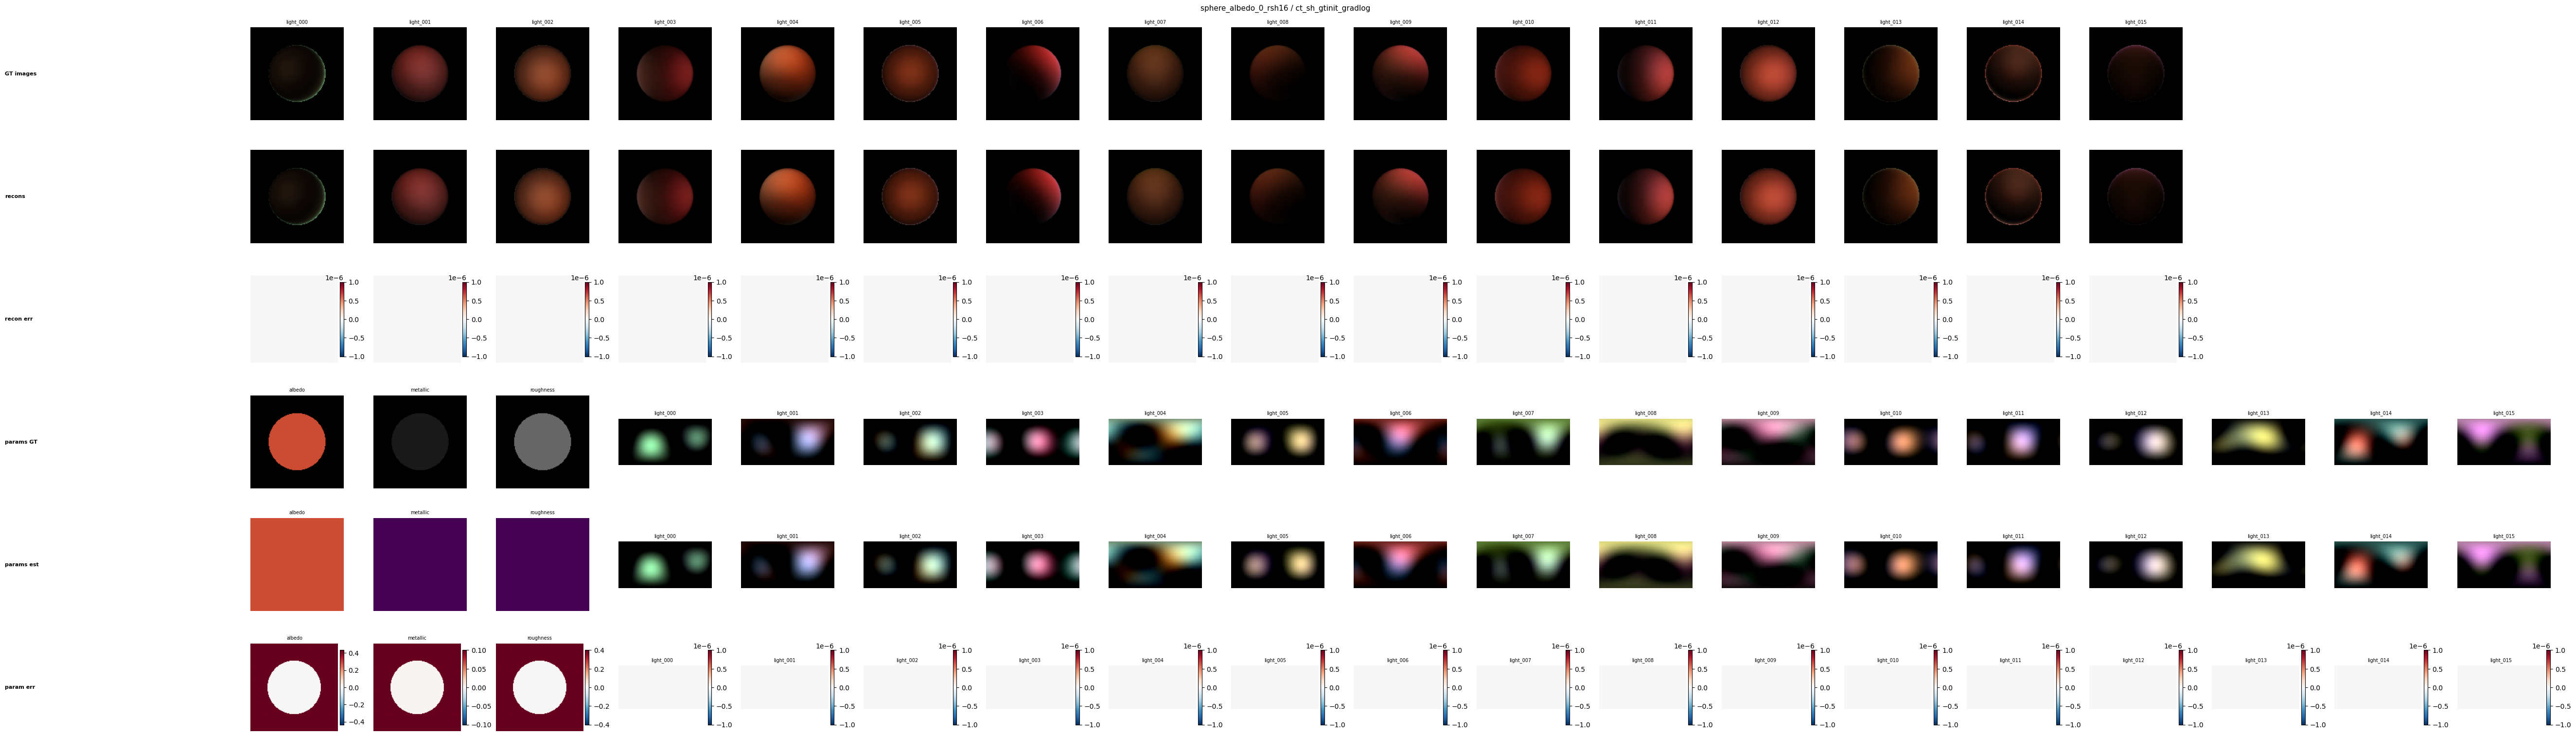

In [47]:
# show_results(scene_id(mode="random_sh", shader=None), "ct_sh_gradlog")
show_results(scene_id(mode="random_sh", shader=None), "ct_sh_gtinit_gradlog")

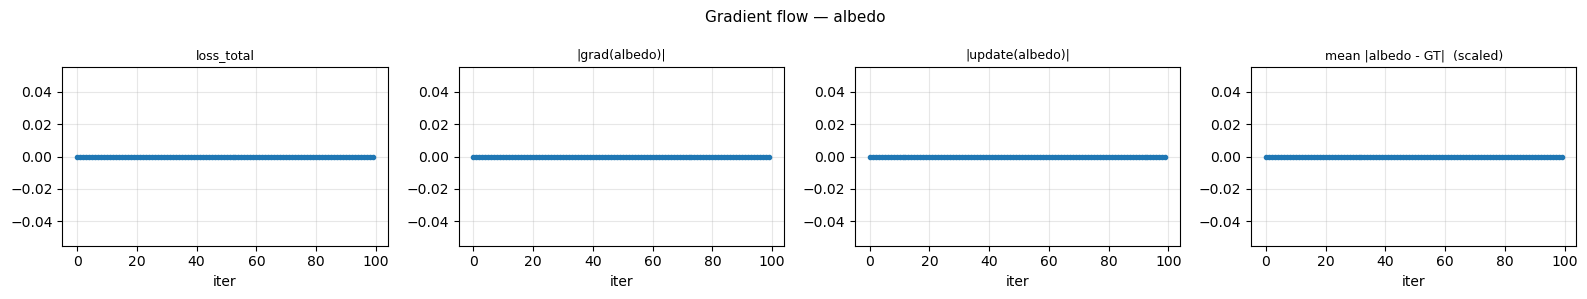

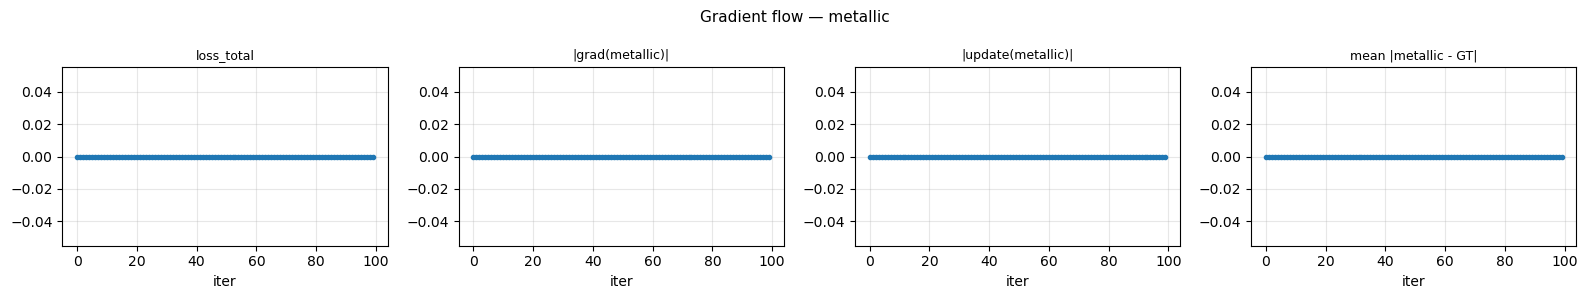

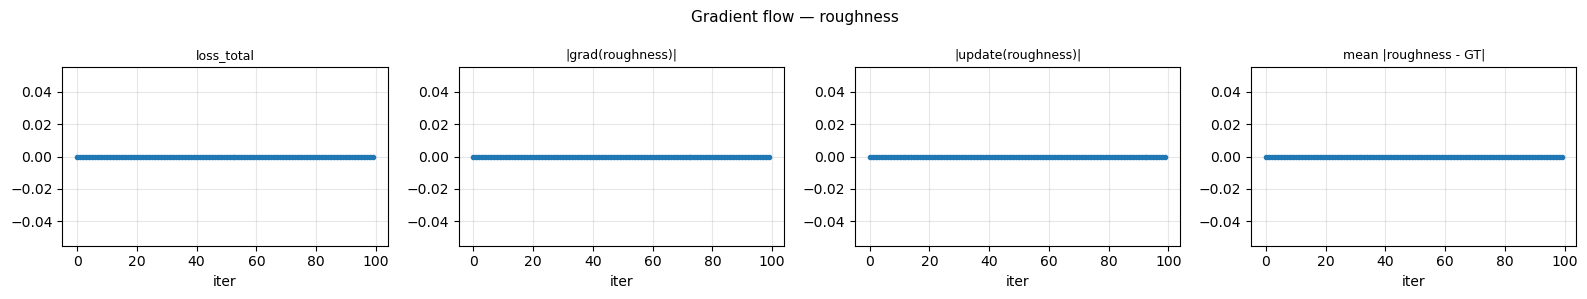

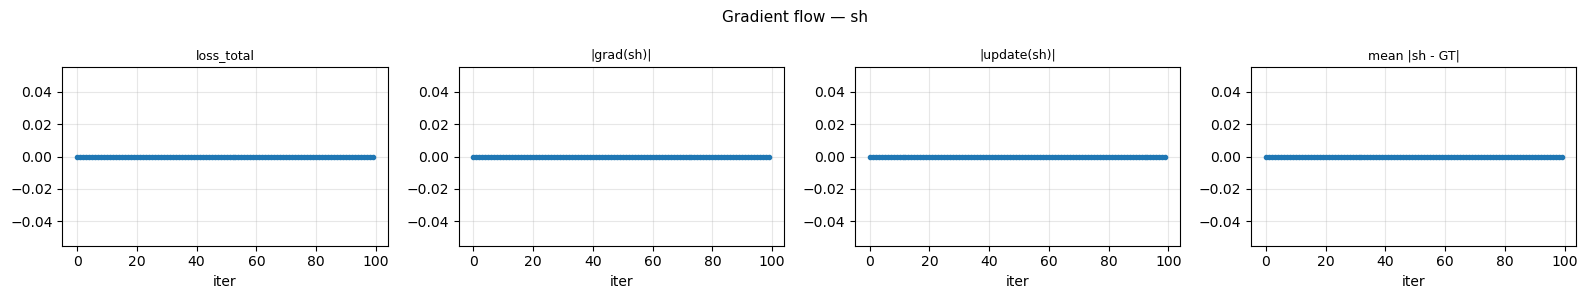

In [48]:
for p in ("albedo", "metallic", "roughness", "sh"):
    plot_grad_flow(ct_grad_dir, param=p)

albedo_scale: [1.0, 1.0, 1.0]


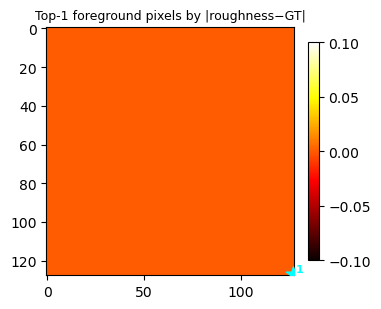

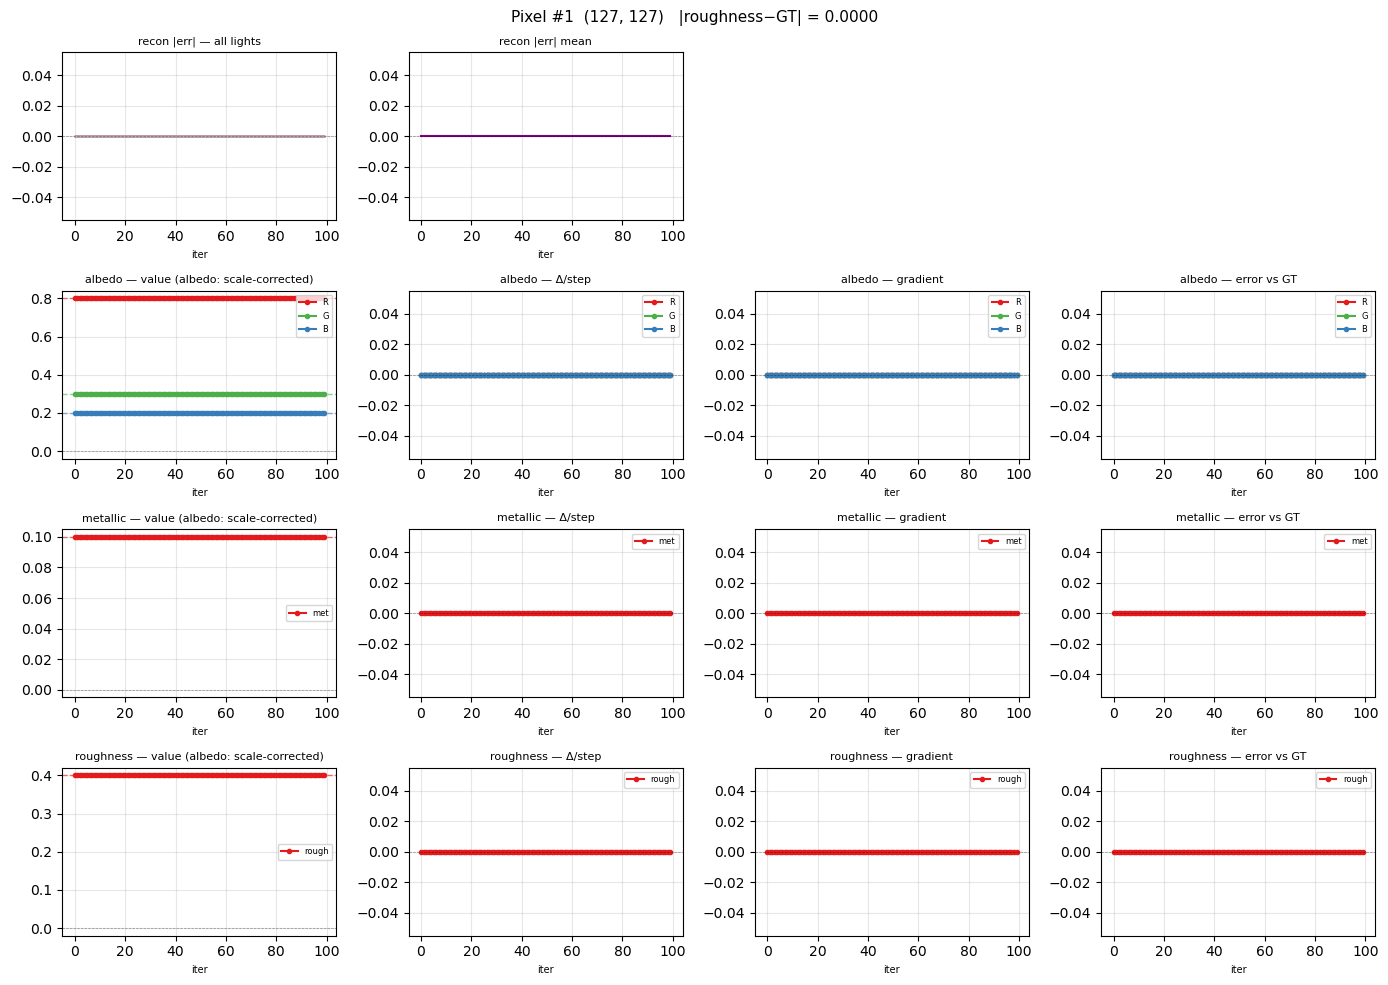

In [49]:
# plot_top_error_pixel_details(ct_grad_dir, scene_id(mode="random_sh", shader=None), "ct_sh", n_top=1, rank_by="albedo")
plot_top_error_pixel_details(ct_grad_dir, scene_id(mode="random_sh", shader=None), "ct_sh", n_top=1, rank_by="roughness")
# plot_top_error_pixel_details(ct_grad_dir, scene_id(mode="random_sh", shader=None), "ct_sh", n_top=1, rank_by="metallic")

## 7 -- Checkerboard textures

Checkerboard patterns are applied in spherical UV space derived from surface normals:
- `u = 0.5 + atan2(nz, nx) / (2*pi)`
- `v = 0.5 - asin(ny) / pi`

A `n_tiles x n_tiles` grid alternates between value A and value B based on cell parity.

**Available configs:**
- CT: `albedo_checker` -- albedo alternates [0.8, 0.3, 0.2] / [0.2, 0.5, 0.8], 4 tiles
- Phong: `albedo_checker` (same albedo), `shininess_checker` (4/63), `ks_checker` (0.1/0.9)

In [65]:
# ── 7a: Phase 1 — render checker scenes ──────────────────────────────────────
for checker_mat in ("albedo_checker", "shininess_checker", "ks_checker"):
    generate_dataset(
        mesh_name="sphere", width=128, height=128,
        shader="phong_sh", device=DEVICE,
        mat_configs_filter={checker_mat},
        light_mode="random_sh", n_lights=N_LIGHTS,
    )
# CT albedo checker
generate_dataset(
    mesh_name="sphere", width=128, height=128,
    shader="ct_sh", device=DEVICE,
    mat_configs_filter={"albedo_checker"},
    light_mode="random_sh", n_lights=N_LIGHTS,
)
print("done: checker renders")

[Phase 1] sphere_phong_albedo_checker_rsh64  done
[Phase 1] Complete.
[Phase 1] sphere_phong_shininess_checker_rsh64  done
[Phase 1] Complete.
[Phase 1] sphere_phong_ks_checker_rsh64  done
[Phase 1] Complete.
[Phase 1] sphere_albedo_checker_rsh64  done
[Phase 1] Complete.
done: checker renders


In [ ]:
# ── 7b: Phase 2 — decompose checker albedo (Phong) ───────────────────────────
run_decomposition(
    mesh_name="sphere", width=128, height=128,
    shader="phong_sh", device=DEVICE,
    mat_configs_filter={"albedo_checker"},
    cfg_overrides={**CFG, "n_iter": 100},
    light_mode="random_sh", n_lights=N_LIGHTS,
    log_gradients=True,
)
print("done: checker albedo decomp")

In [ ]:
# ── 7c: inspect results ───────────────────────────────────────────────────────
show_results(scene_id(mode="random_sh", shader="phong", mat="albedo_checker"), "phong_sh_gradlog")

In [ ]:
chk_grad_dir = results_dir(
    scene_id(mode="random_sh", shader="phong", mat="albedo_checker"),
    "phong_sh_gradlog",
) / "gradient_flow"
for p in ("albedo", "sh", "shininess", "ks"):
    plot_grad_flow(chk_grad_dir, param=p)

In [ ]:
plot_top_error_pixel_details(
    chk_grad_dir,
    scene_id(mode="random_sh", shader="phong", mat="albedo_checker"),
    "phong_sh", n_top=1, rank_by="albedo",
)